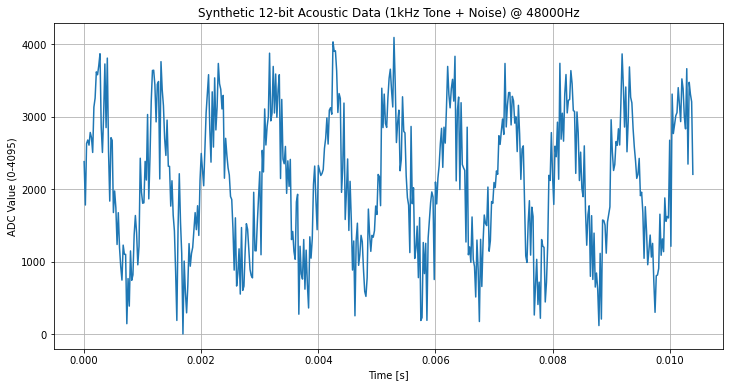

File 'input_signal_1kHzWithNoise.txt' created with 2400 samples.
File 'input_signal.hex' created for Verilog simulation.


In [4]:
# --- PARAMETERS ---
fs = 48000          # Sampling Frequency (48 kHz)
f_tone = 1000       # Target Acoustic Signal (1 kHz)
duration = 0.05     # Duration in seconds (enough for simulation)
bits = 12           # ADC Bit-depth (12-bit = 0 to 4095) - this later used for FPGA
n_noise = 0.2       # for the present project value 0.2 is sufficient, with more it gets clutter 

# 1. Create Time Vector
t = np.linspace(0, duration, int(fs * duration), endpoint=False)

# 2. Generate Clean Signal (Sine Wave)
# An amplitude of 0.6 to leave "headroom" (free space) for noise
clean_signal = 0.6 * np.sin(2 * np.pi * f_tone * t)

# 3. Generate Noise (High-frequency White Noise)
# We simulate a "noisy" environment with 0.2 amplitude
noise = n_noise * np.random.normal(0, 1, len(t))

# 4. Mix Signal and Noise
raw_signal = clean_signal + noise

# 5. Quantization (Converting to Integers for FPGA)
# ADC hardware usually maps -1.0V to +1.0V to a range of 0 to 4095.
# We must shift the signal (add 1) to make it unipolar, then scale.
max_adc_val = (2**bits) - 1
quantized_signal = ((raw_signal + 1) / 2) * max_adc_val
quantized_signal = quantized_signal.astype(int)

# Ensure no values exceed 12-bit range due to noise spikes
quantized_signal = np.clip(quantized_signal, 0, max_adc_val)

# --- VISUALIZATION ---
plt.figure(figsize=(12, 6))
plt.plot(t[:500], quantized_signal[:500]) # Plot first 500 samples
plt.title(f"Synthetic 12-bit Acoustic Data (1kHz Tone + Noise) @ {fs}Hz")
plt.xlabel("Time [s]")
plt.ylabel("ADC Value (0-4095)")
plt.grid(True)
plt.show()

# --- SAVE FOR VERILOG ---
# Saved in Decimal format. Verilog's $readmemh can read Hex, 
# but for simplicity in early testing, save as a text list.
with open("input_signal_1kHzWithNoise.txt", "w") as f:
    for sample in quantized_signal:
        f.write(f"{sample}\n")
        
print(f"File 'input_signal_1kHzWithNoise.txt' created with {len(quantized_signal)} samples.")

with open("input_signal.hex", "w") as f:
    for sample in quantized_signal:
        # '{:03x}' converts the integer to a 3-digit Hex string
        f.write(f"{sample:03x}\n") 
print("File 'input_signal.hex' created for Verilog simulation.")

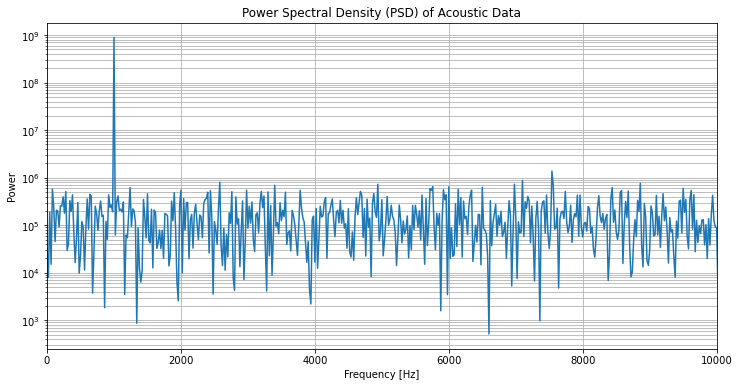

Strongest Frequency detected: 1000.00 Hz


In [5]:
# --- 1. Load the data (simulating reading from a sensor buffer, simulated above) ---
# We use the quantized_signal from the previous task
data = quantized_signal - 2048  # Remove the DC offset to center around 0 for FFT

# --- 2. Perform Fast Fourier Transform (FFT) ---
n = len(data)
freq = np.fft.fftfreq(n, 1/fs)      # Frequency axis
fft_values = np.fft.fft(data)       # Calculate FFT
psd = np.abs(fft_values)**2 / n    # Power Spectral Density

# Only take the positive half of the frequencies (0 to fs/2)
positive_freqs = freq[:n//2]
positive_psd = psd[:n//2]

# --- 3. Visualization ---
plt.figure(figsize=(12, 6))
plt.semilogy(positive_freqs, positive_psd) # Semilog scale is better for noise floor
plt.title("Power Spectral Density (PSD) of Acoustic Data")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Power")
plt.xlim(0, 10000) # Zoom into 0-10kHz to see detail
plt.grid(True, which="both", ls="-")
#plt.axvline(1000, color='r', linestyle='--', label='Target: 1kHz')
#plt.legend()
plt.show()

# --- 4. Identify Filter Requirements ---
target_idx = np.argmax(positive_psd)
target_freq = positive_freqs[target_idx]
print(f"Strongest Frequency detected: {target_freq:.2f} Hz")

--- Copy these into your Verilog Module ---
assign coeff[0] = 16'sd-61;
assign coeff[1] = 16'sd-68;
assign coeff[2] = 16'sd-79;
assign coeff[3] = 16'sd-78;
assign coeff[4] = 16'sd-35;
assign coeff[5] = 16'sd79;
assign coeff[6] = 16'sd293;
assign coeff[7] = 16'sd621;
assign coeff[8] = 16'sd1059;
assign coeff[9] = 16'sd1580;
assign coeff[10] = 16'sd2138;
assign coeff[11] = 16'sd2670;
assign coeff[12] = 16'sd3111;
assign coeff[13] = 16'sd3402;
assign coeff[14] = 16'sd3504;
assign coeff[15] = 16'sd3402;
assign coeff[16] = 16'sd3111;
assign coeff[17] = 16'sd2670;
assign coeff[18] = 16'sd2138;
assign coeff[19] = 16'sd1580;
assign coeff[20] = 16'sd1059;
assign coeff[21] = 16'sd621;
assign coeff[22] = 16'sd293;
assign coeff[23] = 16'sd79;
assign coeff[24] = 16'sd-35;
assign coeff[25] = 16'sd-78;
assign coeff[26] = 16'sd-79;
assign coeff[27] = 16'sd-68;
assign coeff[28] = 16'sd-61;


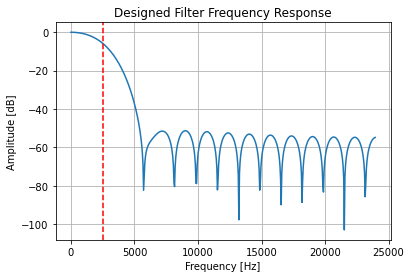

In [12]:
# --- 1. Design the Filter (Floating Point) ---
num_taps = 29           # Number of coefficients (must be an odd number usually)
cutoff_hz = 2500.0      # Our chosen cutoff from Task 2
nyquist = fs / 2
normalized_cutoff = cutoff_hz / nyquist

# Generate FIR coefficients using a Hamming window
coeffs_float = scipy.signal.firwin(num_taps, normalized_cutoff, window='hamming')

# --- 2. Convert to Fixed-Point (The FPGA Step) ---
# We will use 16-bit precision for our coefficients (2^15 = 32768)
scaling_factor = 2**15 
coeffs_int = np.round(coeffs_float * scaling_factor).astype(int)

# --- 3. Output for Verilog ---
print("--- Copy these into your Verilog Module ---")
for i, c in enumerate(coeffs_int):
    print(f"assign coeff[{i}] = 16'sd{c};")

# --- 4. Verify the Filter Response (Visual Proof) ---
w, h = scipy.signal.freqz(coeffs_float)
plt.plot(w/np.pi*nyquist, 20 * np.log10(abs(h)))
plt.title("Designed Filter Frequency Response")
plt.axvline(cutoff_hz, color='red', linestyle='--')
plt.ylabel("Amplitude [dB]")
plt.xlabel("Frequency [Hz]")
plt.grid()
plt.show()

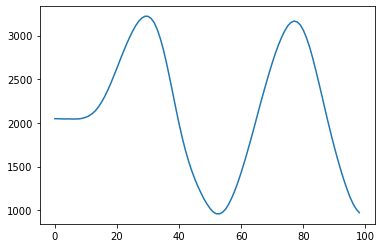

In [32]:
verilog_out = np.loadtxt("verilog_output.txt")
index = 0
for item in verilog_out:
    if item <100:
        verilog_out[index] = item + 4096
    index += 1

#verilog_out[0] = 2048

plt.plot(verilog_out[1:100])

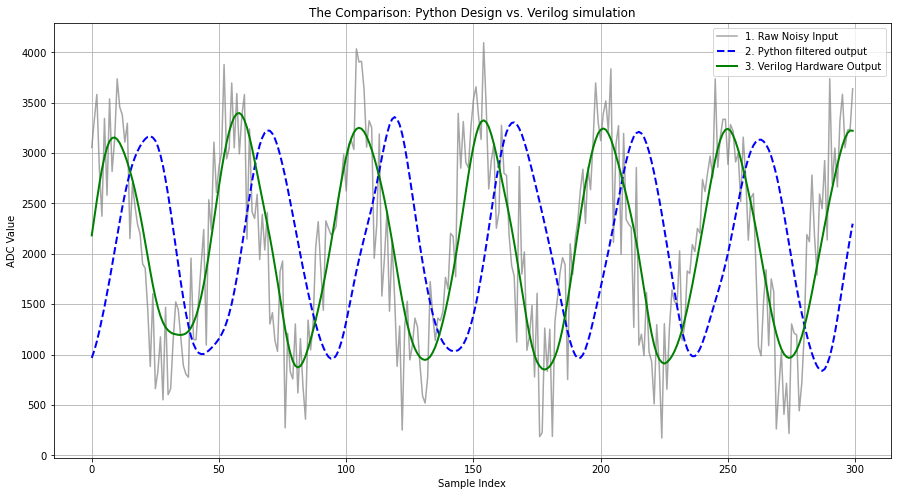

Mathematical Error between Python and Verilog: 1152.39 ADC steps


In [34]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# 1. Load the Data
# original_signal is the 'quantized_signal' from the initial simulation in the first cell
# verilog_output is the result from your simulation
verilog_out = np.loadtxt("verilog_output.txt")
# samll update to correct the depiction
index = 0
for item in verilog_out:
    if item <100:
        verilog_out[index] = item + 4096
    index += 1
# 2. Generate the 'Python Reference' (The Golden Model)
# We use the float coefficients the previous cell FIR simulation 
coeffs_float = signal.firwin(29, 2500.0/(48000/2), window='hamming')
# Scale it to match the ADC range (0-4095)
python_ref = signal.lfilter(coeffs_float, 1.0, quantized_signal - 2048) + 2048

# 3. Handle the Latency (Alignment)
# FIR filters have a delay of (N-1)/2. For 29 taps, that's 14 samples.
# Verilog might have 1-2 extra cycles of clock delay.
delay = 15 

# 4. PLOTTING
plt.figure(figsize=(15, 8))

# Curve 1: The Raw Noisy Data
plt.plot(quantized_signal[100:400], label="1. Raw Noisy Input", color='gray', alpha=0.7)

# Curve 2: The Python Design (The Goal)
plt.plot(python_ref[100:400], label="2. Python filtered output", color='blue', linewidth=2, linestyle='--')

# Curve 3: Verilog simulation results
# We shift it back by the delay to see if it matches the Python curve
plt.plot(verilog_out[100+delay : 400+delay], label="3. Verilog Hardware Output", color='green', linewidth=2)

plt.title("The Comparison: Python Design vs. Verilog simulation")
plt.xlabel("Sample Index")
plt.ylabel("ADC Value")
plt.legend()
plt.grid(True)
plt.show()

# 5. Accuracy Metric: Root Mean Square Error
# How close is the simulation math is to the Python math?
error = np.sqrt(np.mean((python_ref[100:1000] - verilog_out[100+delay:1000+delay])**2))
print(f"Mathematical Error between Python and Verilog: {error:.2f} ADC steps")

In [3]:
# Install libraries if not already present
import scipy
import numpy as np
import matplotlib.pyplot as plt